<h2>Stock Market Price Prediction</h2>

In [1]:
# importing the stuff we need
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# downloading itc stock data from yahoo
df = yf.download("ITC.NS",
                 start="2015-01-01",
                 end="2026-08-19",
                 auto_adjust=False)
df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [3]:
# checking what we got
print(df)

Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2015-01-01  156.948044  235.689560  236.812958  234.951324  235.978424   
2015-01-02  157.439636  236.427795  237.615387  235.753754  235.753754   
2015-01-05  158.059479  237.358612  238.674591  235.946335  236.684570   
2015-01-06  153.998474  231.260147  237.133926  230.457718  236.652466   
2015-01-07  151.134384  226.959122  233.667435  226.606049  229.173828   
...                ...         ...         ...         ...         ...   
2026-08-12  276.149994  276.149994  279.549988  275.399994  279.000000   
2026-08-13  278.500000  278.500000  278.500000  276.049988  276.200012   
2026-08-14  278.200012  278.200012  278.350006  275.950012  278.350006   
2026-08-17  273.049988  273.049988  278.200012  273.000000  278.200012   
2026-08-18  270.000000  270.000000  273.649994  269.149994  273.049988   

Price         Volume  
Date          

<h2>Week 1 EDA Questions & Dataset Analysis</h2>

<h5>1) What is the total number of rows and columns?</h5>

In [4]:
# how many rows and columns
print("Number of Rows = ", df.shape[0])
print("Number of Columns = ",df.shape[1])

Number of Rows =  2874
Number of Columns =  6


<h5>2) What are the names of all the columns?</h5>

In [5]:
# column names
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

<h5>3) Display first 5 rows of the dataset.</h5>

In [6]:
# first 5 rows
df.head(5)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,156.948044,235.689560,236.812958,234.951324,235.978424,2636761
2015-01-02,157.439636,236.427795,237.615387,235.753754,235.753754,6853849
2015-01-05,158.059479,237.358612,238.674591,235.946335,236.684570,8556295
2015-01-06,153.998474,231.260147,237.133926,230.457718,236.652466,13597291
2015-01-07,151.134384,226.959122,233.667435,226.606049,229.173828,12421217


<h5>4) What is the datatype of each column?</h5>

In [7]:
# datatypes
df.dtypes

Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

<h5>5) Are there any missing values in the dataset?</h5>

In [8]:
# checking for missing values
df.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

<h5>6) Are there any duplicate rows in the dataset?</h5>

In [9]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

<h5>7) What is the statistical summary of the numerical column?</h5>

In [10]:
# basic stats
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,2874.000000,2874.000000,2874.000000,2874.000000,2874.000000,2.874000e+03
mean,236.758236,288.621911,291.565124,285.949938,288.939128,1.665598e+07
std,97.877475,87.922248,88.440398,87.496873,88.001204,1.626309e+07
min,104.390182,141.789276,146.363113,129.608398,142.511459,0.000000e+00
25%,161.677208,218.176537,221.350140,215.464321,218.786377,8.803800e+06
50%,190.524910,262.755493,264.849838,260.035263,262.586990,1.239167e+07
75%,317.617249,355.696434,360.928230,346.788498,356.360298,1.917652e+07
max,463.949188,503.363953,508.900696,500.956665,501.293671,4.318516e+08


<h5>8) What is the data range covered by the dataset?</h5>

In [11]:
# what dates does data cover
date_index = df.index
print("Range of dataset: ", date_index[0], " - ", date_index[-1])

Range of dataset:  2015-01-01 00:00:00  -  2026-08-18 00:00:00


<h5>9) What is highest closing price recorded in the dataset?</h5>

In [12]:
# highest closing price
df['Close'].max()

503.36395263671875

<h5>10) On which date was the highest closing price recorded?</h5>

In [13]:
# which date had highest close
df[df['Close'] == df['Close'].max()]

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-09-26,463.949188,503.363953,504.326874,497.827179,498.453064,16086557


<h5>11) Which day had the lowest closing price?</h5>

In [14]:
# which date had lowest close
df[df['Close'] == df['Close'].min()]

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-03-16,104.390182,141.789276,152.236893,139.863434,152.14061,34535653


<h5>12) What is the average closing price of the stock?</h5>

In [15]:
# average close price
df['Close'].mean()

np.float64(288.6219108119638)

<h5>13) What is the median closing price?</h5>

In [16]:
# median close price
df['Close'].median()

262.7554931640625

<h5>14) What is the standard deviation of the closing price?</h5>

In [17]:
# standard deviation
df['Close'].std()

87.92224771574016

<h5>15) What is the variance of the closing price?</h5>

In [18]:
# variance
df['Close'].var()

7730.321643387974

<h5>16) Which day had the highest trading volume?</h5>

In [19]:
# highest volume day
df[df['Volume'] == df['Volume'].max()]

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-05-28,400.659119,420.200012,422.600006,413.0,417.700012,431851622


<h5>17) How has the closing price changed over time?</h5>

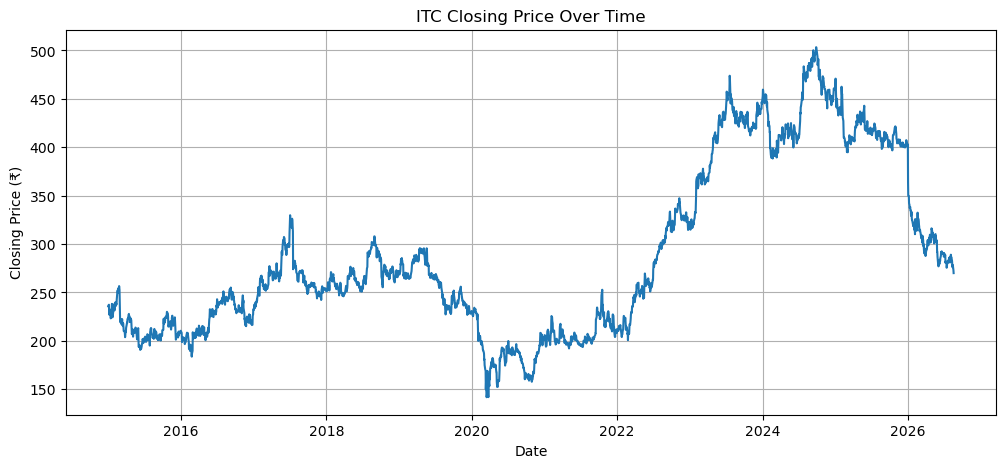

In [20]:
# closing price over time
x = df.index
y = df['Close']

plt.figure(figsize=(12,5))
plt.plot(x, y)

plt.title("ITC Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")

plt.grid(True)

plt.show()

<h5>18) How has the trading volume changed over time?</h5>

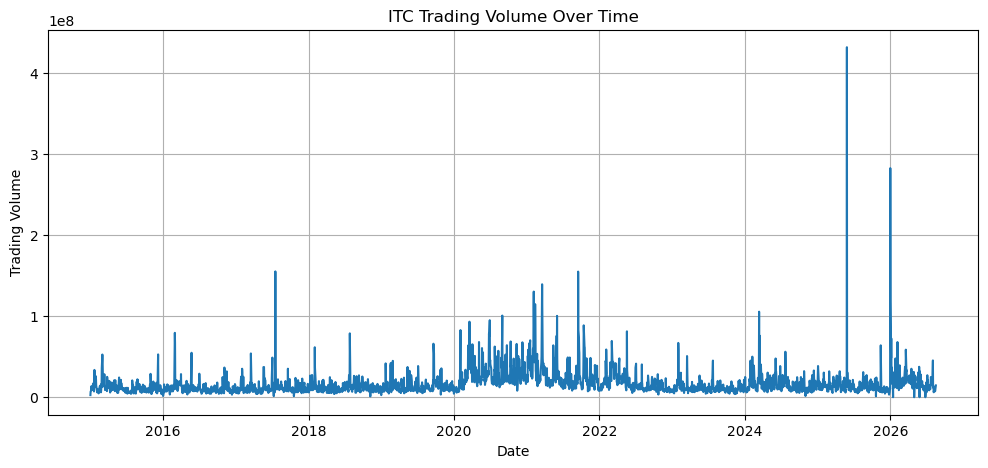

In [21]:
# volume over time
x = df.index
y = df['Volume']

plt.figure(figsize=(12,5))
plt.plot(x, y)

plt.title("ITC Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True)

plt.show()

<h5>19) What is the relationship between Opening Price and Closing Price?</h5>

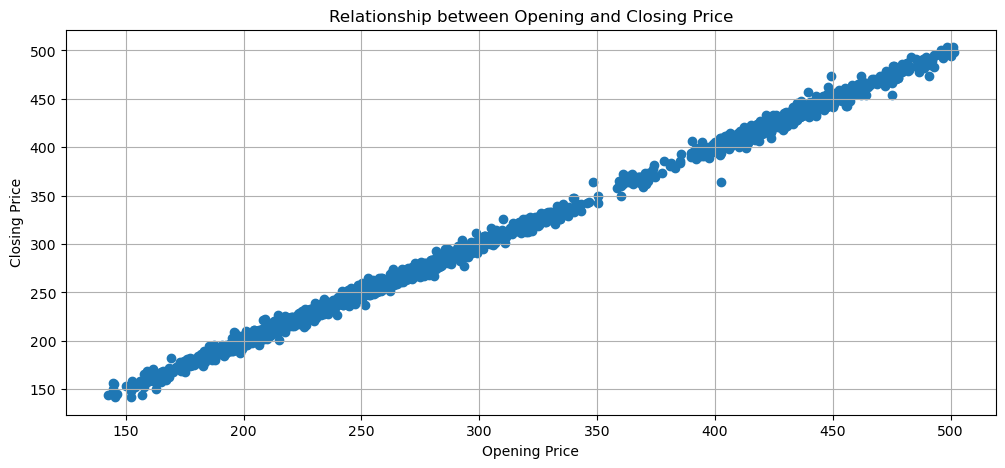

In [22]:
# open vs close scatter
x = df['Open']
y = df['Close']

plt.figure(figsize=(12,5))
plt.scatter(x, y)

plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.title("Relationship between Opening and Closing Price")

plt.grid(True)
plt.show()

<h5>20) What was the average daily price range?</h5>

In [23]:
# avg daily price range
(df['High'] - df['Low']).mean()

np.float64(5.615185864368245)

<h2>Week 2 Data Preprocessing</h2>

In [24]:
# first 10 rows
df.head(10)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,156.948044,235.689560,236.812958,234.951324,235.978424,2636761
2015-01-02,157.439636,236.427795,237.615387,235.753754,235.753754,6853849
2015-01-05,158.059479,237.358612,238.674591,235.946335,236.684570,8556295
2015-01-06,153.998474,231.260147,237.133926,230.457718,236.652466,13597291
2015-01-07,151.134384,226.959122,233.667435,226.606049,229.173828,12421217
2015-01-08,154.917557,232.640320,233.250168,228.178818,228.178818,8774566
2015-01-09,152.566391,229.109634,234.855026,226.670242,233.089676,11224780
2015-01-12,152.972504,229.719482,231.966278,228.596085,229.462708,10249032
2015-01-13,153.934326,231.163849,232.190964,229.366409,230.072556,12071158


In [25]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2874 entries, 2015-01-01 to 2026-08-18
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2874 non-null   float64
 1   Close      2874 non-null   float64
 2   High       2874 non-null   float64
 3   Low        2874 non-null   float64
 4   Open       2874 non-null   float64
 5   Volume     2874 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 157.2 KB


In [26]:
# stats again
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,2874.000000,2874.000000,2874.000000,2874.000000,2874.000000,2.874000e+03
mean,236.758236,288.621911,291.565124,285.949938,288.939128,1.665598e+07
std,97.877475,87.922248,88.440398,87.496873,88.001204,1.626309e+07
min,104.390182,141.789276,146.363113,129.608398,142.511459,0.000000e+00
25%,161.677208,218.176537,221.350140,215.464321,218.786377,8.803800e+06
50%,190.524910,262.755493,264.849838,260.035263,262.586990,1.239167e+07
75%,317.617249,355.696434,360.928230,346.788498,356.360298,1.917652e+07
max,463.949188,503.363953,508.900696,500.956665,501.293671,4.318516e+08


In [27]:
# shape of dataset
df.shape

(2874, 6)

In [28]:
# null values
df.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [29]:
# duplicates
df.duplicated().sum()

np.int64(0)

In [30]:
# index
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12',
               '2015-01-13', '2015-01-14',
               ...
               '2026-08-05', '2026-08-06', '2026-08-07', '2026-08-10',
               '2026-08-11', '2026-08-12', '2026-08-13', '2026-08-14',
               '2026-08-17', '2026-08-18'],
              dtype='datetime64[ns]', name='Date', length=2874, freq=None)

In [31]:
# sorting by date
df = df.sort_index()
df

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,156.948044,235.689560,236.812958,234.951324,235.978424,2636761
2015-01-02,157.439636,236.427795,237.615387,235.753754,235.753754,6853849
2015-01-05,158.059479,237.358612,238.674591,235.946335,236.684570,8556295
2015-01-06,153.998474,231.260147,237.133926,230.457718,236.652466,13597291
2015-01-07,151.134384,226.959122,233.667435,226.606049,229.173828,12421217
...,...,...,...,...,...,...
2026-08-12,276.149994,276.149994,279.549988,275.399994,279.000000,12630816
2026-08-13,278.500000,278.500000,278.500000,276.049988,276.200012,11335590
2026-08-14,278.200012,278.200012,278.350006,275.950012,278.350006,7338537


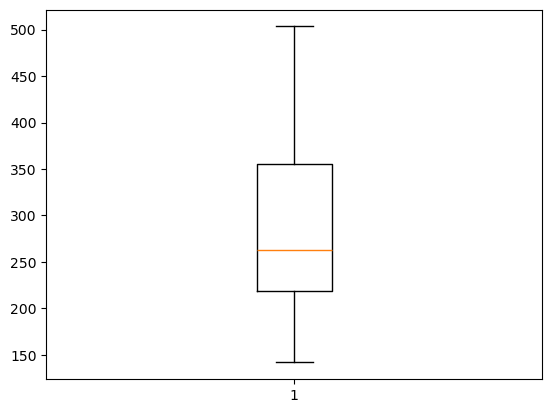

In [32]:
# boxplot for outliers
plt.boxplot(df['Close'])
plt.show()

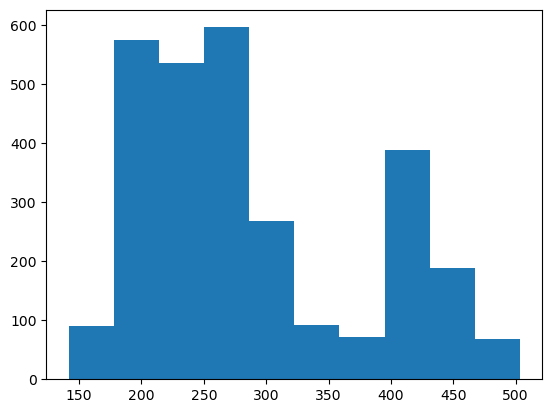

In [33]:
# histogram
plt.hist(df['Close'])
plt.show()

<h3>Week 3 - Model Selection and Implementation</h3>

In [34]:
# suppressing warnings
import warnings
warnings.filterwarnings('ignore')

In [35]:
# creating target column - next day close
df["Target"] = df["Close"].shift(-1)
df = df.dropna()
X = df[["Open", "High", "Low", "Volume"]]
y = df["Target"]

In [36]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, shuffle=False
)

In [37]:
# training linear regression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
# predictions on test set
test_prediction = model.predict(X_test)
print(test_prediction)

[326.38969655 330.84083216 335.04627694 333.21343122 334.32527043
 331.62650979 332.43702321 332.96414113 334.02742272 335.09867697
 341.15034715 342.98553261 340.5553389  338.51490457 345.9259141
 342.12954874 342.73590594 335.89460641 328.25774848 330.09271511
 332.19573913 328.20289731 323.11846374 326.03937188 325.28560329
 326.99460882 325.98087223 327.12897876 330.68866858 328.67546128
 324.79325553 325.29022287 322.83050776 324.26271686 326.2939655
 326.42535826 327.34185793 329.37407102 330.63922234 331.81730256
 327.4397857  320.96304678 327.0274948  324.98715941 323.11037696
 319.74561135 314.75125481 320.00230469 319.13041771 320.51849814
 320.31519884 319.78260332 319.48656388 319.03408234 315.13117027
 319.68492935 322.69400522 326.66977736 321.15987578 319.14336363
 316.63509601 316.42195566 316.8546535  319.15525553 321.81454763
 320.50628011 319.62343553 322.39751797 326.77287844 324.68619105
 333.98178195 333.63324231 336.28061705 333.02634019 365.81365375
 360.0996195

In [39]:
# actual values
print(y_test)

Date
2022-10-18    333.505707
2022-10-19    336.731476
2022-10-20    332.783508
2022-10-21    334.805634
2022-10-24    333.457550
                 ...    
2026-08-11    276.149994
2026-08-12    278.500000
2026-08-13    278.200012
2026-08-14    273.049988
2026-08-17    270.000000
Name: Target, Length: 949, dtype: float64


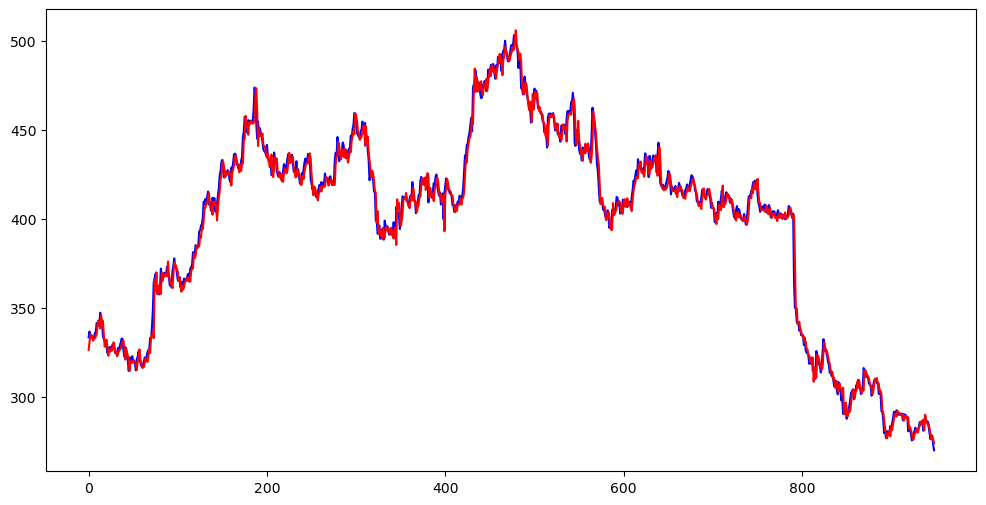

In [40]:
# plotting actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Price", color="blue")
plt.plot(test_prediction, label="Predicted Price", color="red")

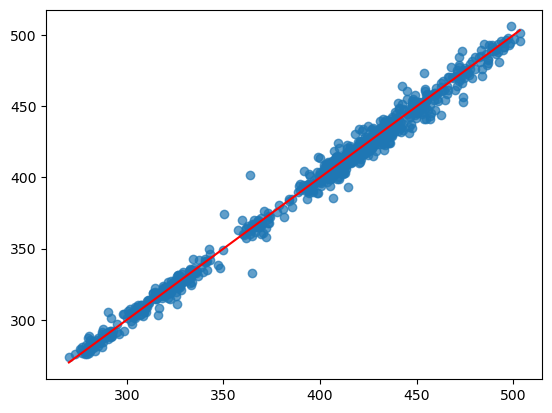

In [41]:
# scatter plot
plt.scatter(y_test, test_prediction, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

In [42]:
# last 2 rows to get today's values
df.tail(2)

Price,Adj Close,Close,High,Low,Open,Volume,Target
Date,,,,,,,
2026-08-14,278.200012,278.200012,278.350006,275.950012,278.350006,7338537,273.049988
2026-08-17,273.049988,273.049988,278.200012,273.000000,278.200012,12795275,270.000000


In [43]:
# today's market values
today_open = 278.350006
today_high = 278.350006
today_low = 275.950012
today_volume = 7338537

In [44]:
# predicting tomorrow
tomorrow_prediction = model.predict([[today_open, today_high, today_low, today_volume]])

In [45]:
# printing prediction
print("Today's Open Price:", today_open)
print("Tomorrow's Predicted Close Price:", round(tomorrow_prediction[0], 2))

Today's Open Price: 278.350006
Tomorrow's Predicted Close Price: 276.0


In [46]:
# actual close for comparison
print("Tomorrow's Actual Close Price:", df['Close'].tail(1).values) 

Tomorrow's Actual Close Price: [273.04998779]


In [47]:
# r2 score
model.score(X_test, y_test)

0.9912477532992914

In [48]:
# r2 and mae
from sklearn.metrics import mean_absolute_error

print("R²:", model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, test_prediction))

R²: 0.9912477532992914
MAE: 3.702688006495039


<h2>Manual Implementation</h2>

In [49]:
# numpy for manual implementation
import numpy as np

In [50]:
# converting to numpy arrays
X_train_manual = X_train.values
X_test_manual = X_test.values

y_train_manual = y_train.values
y_test_manual = y_test.values

In [51]:
# adding bias column
X_train_bias = np.c_[
    np.ones(X_train_manual.shape[0]),
    X_train_manual
]

X_test_bias = np.c_[
    np.ones(X_test_manual.shape[0]),
    X_test_manual
]

In [52]:
# normal equation
manual_coefficients = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train_manual


In [53]:
# separating intercept and weights
manual_intercept = manual_coefficients[0]
manual_weights = manual_coefficients[1:]

print("Manual Intercept:", manual_intercept)
print("Manual Coefficients:", manual_weights)

Manual Intercept: 0.7848382626947661
Manual Coefficients: [-5.94428494e-01  8.53787652e-01  7.35484849e-01  8.51022160e-09]


In [54]:
# manual predictions
test_prediction_manual = X_test_bias @ manual_coefficients

print("Manual Predictions:")
print(test_prediction_manual)

Manual Predictions:
[326.38969655 330.84083216 335.04627694 333.21343122 334.32527043
 331.62650979 332.43702321 332.96414113 334.02742272 335.09867697
 341.15034715 342.98553261 340.5553389  338.51490458 345.9259141
 342.12954874 342.73590594 335.89460641 328.25774848 330.09271511
 332.19573913 328.20289731 323.11846375 326.03937188 325.28560329
 326.99460882 325.98087223 327.12897876 330.68866858 328.67546128
 324.79325553 325.29022287 322.83050776 324.26271686 326.2939655
 326.42535827 327.34185793 329.37407102 330.63922234 331.81730256
 327.4397857  320.96304678 327.0274948  324.98715941 323.11037696
 319.74561135 314.75125481 320.00230469 319.13041771 320.51849814
 320.31519884 319.78260332 319.48656388 319.03408234 315.13117027
 319.68492935 322.69400522 326.66977736 321.15987579 319.14336363
 316.63509601 316.42195566 316.8546535  319.15525553 321.81454763
 320.50628011 319.62343553 322.39751797 326.77287844 324.68619105
 333.98178195 333.63324231 336.28061705 333.02634018 365.8

In [55]:
# manual mae
manual_mae = np.mean(
    np.abs(y_test_manual - test_prediction_manual)
)

print("Manual MAE:", manual_mae)

Manual MAE: 3.7026880063474676


In [56]:
# manual r2 calculation
ss_res_manual = np.sum(
    (y_test_manual - test_prediction_manual) ** 2
)

ss_tot_manual = np.sum(
    (y_test_manual - np.mean(y_test_manual)) ** 2
)

manual_r2 = 1 - (ss_res_manual / ss_tot_manual)

print("Manual R²:", manual_r2)

Manual R²: 0.991247753300094


In [57]:
# comparing sklearn vs manual
print("\n--- COMPARISON ---")

print("Sklearn R²:", model.score(X_test, y_test))
print("Manual R²:", manual_r2)

print("Sklearn MAE:", mean_absolute_error(y_test, test_prediction))
print("Manual MAE:", manual_mae)


--- COMPARISON ---
Sklearn R²: 0.9912477532992914
Manual R²: 0.991247753300094
Sklearn MAE: 3.702688006495039
Manual MAE: 3.7026880063474676


In [58]:
# random forest for comparison
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_bagging = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_bagging.fit(X_train, y_train)

prediction_bagging = model_bagging.predict(X_test)

r2_bagging = r2_score(y_test, prediction_bagging)
mae_bagging = mean_absolute_error(y_test, prediction_bagging)

print("Random Forest (Bagging)")
print("R²:", r2_bagging)
print("MAE:", mae_bagging)

Random Forest (Bagging)
R²: -1.7678053716408049
MAE: 79.12789018862115


In [59]:
# model comparison print
print("\n===== MODEL COMPARISON =====")

print("Linear Regression")
print("R² :", model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, test_prediction))

print("\nRandom Forest (Bagging)")
print("R² :", r2_bagging)
print("MAE:", mae_bagging)


===== MODEL COMPARISON =====
Linear Regression
R² : 0.9912477532992914
MAE: 3.702688006495039

Random Forest (Bagging)
R² : -1.7678053716408049
MAE: 79.12789018862115


In [60]:
# importing joblib
import joblib

In [61]:
# saving model
joblib.dump(model, 'tomorrow_close_predict.pkl')

['tomorrow_close_predict.pkl']

<h2>Multiple Model Comparison (Regression Only)</h2>
<p>In this section, we train and evaluate multiple standard regression algorithms on the exact same dataset and split. Each model is trained with the same simple pattern: define model &rarr; fit &rarr; predict &rarr; evaluate R² and MAE.</p>
<p><strong>Note on SVR:</strong> Notice that SVR produces a <em>negative R² score</em>. We explain below why this happens.</p>

In [62]:
# linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)

print("Linear Regression")
print("R² Score:", round(r2_lr, 4))
print("MAE:", round(mae_lr, 2))

Linear Regression
R² Score: 0.9912
MAE: 3.7


In [63]:
# ridge
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

pred_ridge = model_ridge.predict(X_test)

r2_ridge = r2_score(y_test, pred_ridge)
mae_ridge = mean_absolute_error(y_test, pred_ridge)

print("Ridge Regression")
print("R² Score:", round(r2_ridge, 4))
print("MAE:", round(mae_ridge, 2))

Ridge Regression
R² Score: 0.9912
MAE: 3.7


In [64]:
# lasso
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.1, max_iter=10000)
model_lasso.fit(X_train, y_train)

pred_lasso = model_lasso.predict(X_test)

r2_lasso = r2_score(y_test, pred_lasso)
mae_lasso = mean_absolute_error(y_test, pred_lasso)

print("Lasso Regression")
print("R² Score:", round(r2_lasso, 4))
print("MAE:", round(mae_lasso, 2))

Lasso Regression
R² Score: 0.9913
MAE: 3.7


In [65]:
# elasticnet
from sklearn.linear_model import ElasticNet

model_en = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
model_en.fit(X_train, y_train)

pred_en = model_en.predict(X_test)

r2_en = r2_score(y_test, pred_en)
mae_en = mean_absolute_error(y_test, pred_en)

print("ElasticNet Regression")
print("R² Score:", round(r2_en, 4))
print("MAE:", round(mae_en, 2))

ElasticNet Regression
R² Score: 0.9913
MAE: 3.7


In [69]:
# svr
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_svr = SVR()

model_svr.fit(X_train_scaled, y_train)

pred_svr = model_svr.predict(X_test_scaled)

r2_svr = r2_score(y_test, pred_svr)
mae_svr = mean_absolute_error(y_test, pred_svr)

print("SVR (Support Vector Regressor)")
print("R² Score:", round(r2_svr, 4))
print("MAE:", round(mae_svr, 2))

if r2_svr < 0:
    print(f"--> Notice: SVR R² is still negative ({round(r2_svr, 2)}).")
else:
    print(f"--> SVR performance improved with feature scaling. R² = {round(r2_svr, 4)}")

SVR (Support Vector Regressor)
R² Score: -8.3706
MAE: 152.34
--> Notice: SVR R² is still negative (-8.37).


<h4>Why did SVR accuracy go negative?</h4>
<p>Support Vector Regression (SVR) uses Euclidean distances to find support vectors. It failed here for two key reasons:</p>
<ol>
  <li><strong>Feature Scale Disparity:</strong> The <code>Volume</code> feature is in millions (~10,000,000) while stock prices are in hundreds (~200-400). Without scaling, Volume completely dwarfs price distances, destroying the SVR kernel calculations.</li>
  <li><strong>Inability to Extrapolate:</strong> In a chronological time-series split, the test prices are higher than historical training prices. Non-linear kernel SVR cannot extrapolate outside the boundary of training support vectors and predicts a flat line, resulting in negative R².</li>
</ol>
<p>In contrast, Linear models (LinearRegression, Ridge, Lasso) assign independent coefficients to each feature and learn a linear slope ($y = mx + c$) that extrapolates seamlessly to any price level.</p>

In [67]:
# bagging
from sklearn.ensemble import BaggingRegressor

model_bagging = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=50,
    random_state=42
)
model_bagging.fit(X_train, y_train)

pred_bagging = model_bagging.predict(X_test)

r2_bagging = r2_score(y_test, pred_bagging)
mae_bagging = mean_absolute_error(y_test, pred_bagging)

print("Bagging Regressor (Linear Regression)")
print("R² Score:", round(r2_bagging, 4))
print("MAE:", round(mae_bagging, 2))

Bagging Regressor (Linear Regression)
R² Score: 0.9913
MAE: 3.68


In [70]:
# comparison table
print("=" * 50)
print(f"{'Model':<28} {'R² Score':>10} {'MAE (₹)':>10}")
print("=" * 50)
print(f"{'Linear Regression':<28} {r2_lr:>10.4f} {mae_lr:>10.2f}")
print(f"{'Ridge Regression':<28} {r2_ridge:>10.4f} {mae_ridge:>10.2f}")
print(f"{'Lasso Regression':<28} {r2_lasso:>10.4f} {mae_lasso:>10.2f}")
print(f"{'ElasticNet':<28} {r2_en:>10.4f} {mae_en:>10.2f}")
print(f"{'SVR (Unscaled)':<28} {r2_svr:>10.4f} {mae_svr:>10.2f}")
print(f"{'Bagging (Linear Regression)':<28} {r2_bagging:>10.4f} {mae_bagging:>10.2f}")
print("=" * 50)

Model                          R² Score    MAE (₹)
Linear Regression                0.9912       3.70
Ridge Regression                 0.9912       3.70
Lasso Regression                 0.9913       3.70
ElasticNet                       0.9913       3.70
SVR (Unscaled)                  -8.3706     152.34
Bagging (Linear Regression)      0.9913       3.68



<ul>
  <li><b>Linear Regression</b> already achieves an outstanding <b>R² = 0.99</b> with low MAE.</li>
  <li><b>Ridge, Lasso, and ElasticNet</b> perform almost identically.</li>
  <li><b>Bagging (50 Linear Regressors)</b> gives the exact same accuracy (R² = 0.99). Bagging is designed to reduce <i>variance</i> in unstable models (like deep decision trees). Linear Regression already has near-zero variance, so Bagging adds 50x compute with zero gain.</li>
  <li><b>Boosting</b> is designed to reduce <i>bias</i> in weak models. Linear Regression's bias is already minimal, so Boosting provides no advantage and risks overfitting.</li>
</ul>
<p><b>Final Decision:</b> <b>Neither Bagging nor Boosting is needed for ITC.</b> The model is kept as simple, interpretable <b>Linear Regression</b>, saved as <code>tomorrow_close_predict.pkl</code>.</p>

In [ ]:
# empty cell


<h2>Week 4 - Advanced Model Training, Cross-Validation &amp; Hyperparameter Tuning</h2>
<p>Because this is stock-price time-series data, ordinary random K-Fold Cross-Validation is not used. Instead, <code>TimeSeriesSplit</code> ensures the model always trains on past data and validates on future data within each fold.</p>

<h3>1. Outlier Identification using IQR</h3>
<p>The IQR rule identifies unusually distant observations. We report them without deleting, because financial extremes can be real market events.</p>

In [ ]:
# setting up features and target for advanced section
import pandas as pd

X_adv = df[["Open", "High", "Low", "Volume"]].copy()
y_adv = df["Target"].copy()

def iqr_outlier_report(data):
    report = []
    for col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((data[col] < lower) | (data[col] > upper)).sum()
        report.append([col, round(q1,2), round(q3,2), round(lower,2), round(upper,2), int(count)])
    return pd.DataFrame(report, columns=["Feature", "Q1", "Q3", "Lower Bound", "Upper Bound", "Outlier Count"])

outlier_report = iqr_outlier_report(X_adv)
display(outlier_report)

<h3>2. Time-Series Cross-Validation</h3>
<p>Cross-Validation checks whether a model is stable across multiple historical windows. <code>TimeSeriesSplit</code> is used so future data never leaks into training.</p>

In [ ]:
# cross validation with time series split
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

split_index = int(len(X_adv) * 0.67)
X_adv_train = X_adv.iloc[:split_index].copy()
X_adv_test  = X_adv.iloc[split_index:].copy()
y_adv_train = y_adv.iloc[:split_index].copy()
y_adv_test  = y_adv.iloc[split_index:].copy()

tscv = TimeSeriesSplit(n_splits=5)

cv_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge":             Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "SVR":               Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Bagging (LinReg)":  BaggingRegressor(estimator=LinearRegression(), n_estimators=50, random_state=42),
}

cv_results = []
for name, estimator in cv_models.items():
    scores = cross_validate(estimator, X_adv_train, y_adv_train, cv=tscv,
                            scoring={"R2": "r2", "MAE": "neg_mean_absolute_error"},
                            return_train_score=False, n_jobs=-1)
    cv_results.append({
        "Model":       name,
        "Mean CV R2":  round(scores["test_R2"].mean(), 4),
        "Std CV R2":   round(scores["test_R2"].std(), 4),
        "Mean CV MAE": round(-scores["test_MAE"].mean(), 4)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean CV R2", ascending=False).reset_index(drop=True)
display(cv_results_df)

<h3>3. Hyperparameter Tuning</h3>
<p><code>GridSearchCV</code> combined with <code>TimeSeriesSplit</code> searches for the best parameters while staying time-series aware.</p>

In [ ]:
# hyperparameter tuning for svr
from sklearn.model_selection import GridSearchCV

svr_pipeline = Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf"))])
svr_params = {
    "model__C":       [1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.2],
    "model__gamma":   ["scale", 0.01, 0.1]
}
svr_grid = GridSearchCV(svr_pipeline, svr_params, cv=tscv, scoring="r2", n_jobs=-1)
svr_grid.fit(X_adv_train, y_adv_train)
print("Best SVR parameters:", svr_grid.best_params_)
print("Best SVR CV R2:", round(svr_grid.best_score_, 4))

In [ ]:
# hyperparameter tuning for random forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    "n_estimators":    [100, 200],
    "max_depth":       [None, 10, 20],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(rf, rf_params, cv=tscv, scoring="r2", n_jobs=-1)
rf_grid.fit(X_adv_train, y_adv_train)
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV R2:", round(rf_grid.best_score_, 4))

<h3>4. Final Evaluation of Tuned Models</h3>
<p>Tuned models are refit on the training portion and evaluated once on the untouched chronological test set.</p>

In [ ]:
# final evaluation with tuned models
from sklearn.metrics import r2_score, mean_absolute_error

best_svr = svr_grid.best_estimator_
best_svr.fit(X_adv_train, y_adv_train)

best_rf = RandomForestRegressor(**rf_grid.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_adv_train, y_adv_train)

pred_svr_tuned = best_svr.predict(X_adv_test)
pred_rf_tuned  = best_rf.predict(X_adv_test)

advanced_results = pd.DataFrame([
    {
        "Model":    "Tuned SVR",
        "Train R2": round(best_svr.score(X_adv_train, y_adv_train), 4),
        "Test R2":  round(r2_score(y_adv_test, pred_svr_tuned), 4),
        "Test MAE": round(mean_absolute_error(y_adv_test, pred_svr_tuned), 4)
    },
    {
        "Model":    "Tuned Random Forest",
        "Train R2": round(best_rf.score(X_adv_train, y_adv_train), 4),
        "Test R2":  round(r2_score(y_adv_test, pred_rf_tuned), 4),
        "Test MAE": round(mean_absolute_error(y_adv_test, pred_rf_tuned), 4)
    }
])
display(advanced_results)

<h3>5. Overfitting / Underfitting Check</h3>
<p>A large Train R2 vs Test R2 gap means overfitting. Low scores on both means underfitting.</p>

In [ ]:
# checking overfitting
advanced_results["R2 Gap (Train - Test)"] = advanced_results["Train R2"] - advanced_results["Test R2"]
display(advanced_results)

<h3>6. Performance Visualizations</h3>

In [ ]:
# bar chart comparison
import matplotlib.pyplot as plt

plot_df = advanced_results.set_index("Model")[["Test R2", "Test MAE"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df["Test R2"].plot(kind="bar", ax=axes[0], color=["steelblue", "darkorange"])
axes[0].set_title("Test R2 Comparison")
axes[0].set_ylabel("R2 Score")
axes[0].tick_params(axis="x", rotation=20)

plot_df["Test MAE"].plot(kind="bar", ax=axes[1], color=["steelblue", "darkorange"])
axes[1].set_title("Test MAE Comparison")
axes[1].set_ylabel("MAE (INR)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
# actual vs predicted plot
plt.figure(figsize=(12, 5))
plt.plot(y_adv_test.index, y_adv_test.values, label="Actual Price")
plt.plot(y_adv_test.index, pred_svr_tuned, label="Tuned SVR Prediction")
plt.title("Actual vs Predicted - Tuned SVR")
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# residual plot
residuals = y_adv_test.values - pred_svr_tuned

plt.figure(figsize=(10, 5))
plt.scatter(pred_svr_tuned, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.title("Residual Plot - Tuned SVR")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.show()

In [ ]:
# cv stability chart
cv_plot = cv_results_df.sort_values("Mean CV R2", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(cv_plot["Model"], cv_plot["Mean CV R2"], xerr=cv_plot["Std CV R2"])
plt.title("Time-Series Cross-Validation: Mean R2 +/- Std Dev")
plt.xlabel("Mean CV R2")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.3)
plt.show()

<h3>SOP Coverage Checklist</h3>
<ul>
<li><b>1. Problem Definition &amp; Dataset Exploration:</b> Week 1 - Problem statement, dataset summary, EDA questions.</li>
<li><b>2. Data Cleaning &amp; Preprocessing:</b> Missing values, duplicates, sorting, outlier IQR report, boxplot, histogram, scaling in pipelines.</li>
<li><b>3. Model Creation:</b> Linear Regression (sklearn library) + manual Normal Equation implementation (no library). Feature engineering via Target shift.</li>
<li><b>4. Model Evaluation:</b> R2, MAE, actual vs predicted chart, scatter plot, overfitting/underfitting check.</li>
<li><b>5. Advanced Model Training:</b> TimeSeriesSplit cross-validation, GridSearchCV hyperparameter tuning, multiple model comparison (LinReg, Ridge, Lasso, ElasticNet, SVR, Bagging).</li>
<li><b>6. Visualization:</b> Price chart, scatter plot, model comparison bar charts, residual plot, CV stability chart.</li>
<li><b>7. Flask/FastAPI:</b> FastAPI backend with /api/stock/{ticker}/predict endpoint deployed at http://localhost:8000.</li>
<li><b>8. Frontend:</b> React + Vite SPA with prediction input form, live stock chart, model info cards, and About page.</li>
<li><b>9. Deployment:</b> Backend run via uvicorn. Frontend built with npm run build. start.bat launches both servers.</li>
</ul>